In [16]:
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train-Test Split
from sklearn.model_selection import train_test_split

# Feature Scaling
from sklearn.preprocessing import StandardScaler

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [17]:
df = pd.read_csv("novagen_dataset.csv")

# Display first 5 rows
print(df.head())

    Age   BMI  Blood_Pressure  Cholesterol  Glucose_Level  Heart_Rate  \
0   2.0  26.0           111.0        198.0           99.0        72.0   
1   8.0  24.0           121.0        199.0          103.0        75.0   
2  81.0  27.0           147.0        203.0          100.0        74.0   
3  25.0  21.0           150.0        199.0          102.0        70.0   
4  24.0  26.0           146.0        202.0           99.0        76.0   

   Sleep_Hours  Exercise_Hours  Water_Intake  Stress_Level  ...  Diet  \
0          4.0             1.0           5.0           5.0  ...     1   
1          2.0             1.0           2.0           9.0  ...     1   
2         10.0            -0.0           5.0           1.0  ...     2   
3          7.0             3.0           3.0           3.0  ...     1   
4         10.0             2.0           5.0           1.0  ...     2   

   MentalHealth  PhysicalActivity  MedicalHistory  Allergies  \
0             2                 1               0         

In [18]:
df

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,...,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type__Vegan,Diet_Type__Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O
0,2.0,26.0,111.0,198.0,99.0,72.0,4.0,1.0,5.0,5.0,...,1,2,1,0,1,False,True,True,False,False
1,8.0,24.0,121.0,199.0,103.0,75.0,2.0,1.0,2.0,9.0,...,1,2,1,2,2,False,False,True,False,False
2,81.0,27.0,147.0,203.0,100.0,74.0,10.0,-0.0,5.0,1.0,...,2,0,0,1,0,True,False,False,False,False
3,25.0,21.0,150.0,199.0,102.0,70.0,7.0,3.0,3.0,3.0,...,1,2,1,2,0,True,False,False,True,False
4,24.0,26.0,146.0,202.0,99.0,76.0,10.0,2.0,5.0,1.0,...,2,0,2,0,2,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9544,5.0,22.0,109.0,203.0,98.0,75.0,8.0,1.0,6.0,0.0,...,0,2,2,1,0,True,False,True,False,False
9545,94.0,26.0,144.0,203.0,96.0,72.0,8.0,4.0,2.0,1.0,...,1,0,1,0,2,False,True,False,True,False
9546,10.0,23.0,185.0,198.0,103.0,72.0,4.0,5.0,5.0,6.0,...,1,0,2,0,1,True,False,True,False,False
9547,50.0,29.0,166.0,200.0,100.0,74.0,8.0,2.0,3.0,4.0,...,2,0,0,1,1,True,False,True,False,False


In [19]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(9549, 23)


In [20]:
print("\nColumn Names:")
print(df.columns)



Column Names:
Index(['Age', 'BMI', 'Blood_Pressure', 'Cholesterol', 'Glucose_Level',
       'Heart_Rate', 'Sleep_Hours', 'Exercise_Hours', 'Water_Intake',
       'Stress_Level', 'Target', 'Smoking', 'Alcohol', 'Diet', 'MentalHealth',
       'PhysicalActivity', 'MedicalHistory', 'Allergies', 'Diet_Type__Vegan',
       'Diet_Type__Vegetarian', 'Blood_Group_AB', 'Blood_Group_B',
       'Blood_Group_O'],
      dtype='str')


In [21]:
print("\nDataset Information:")
print(df.info())


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 9549 entries, 0 to 9548
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    9549 non-null   float64
 1   BMI                    9549 non-null   float64
 2   Blood_Pressure         9549 non-null   float64
 3   Cholesterol            9549 non-null   float64
 4   Glucose_Level          9549 non-null   float64
 5   Heart_Rate             9549 non-null   float64
 6   Sleep_Hours            9549 non-null   float64
 7   Exercise_Hours         9549 non-null   float64
 8   Water_Intake           9549 non-null   float64
 9   Stress_Level           9549 non-null   float64
 10  Target                 9549 non-null   int64  
 11  Smoking                9549 non-null   int64  
 12  Alcohol                9549 non-null   int64  
 13  Diet                   9549 non-null   int64  
 14  MentalHealth           9549 non-null   int64 

In [23]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
               Age          BMI  Blood_Pressure  Cholesterol  Glucose_Level  \
count  9549.000000  9549.000000     9549.000000  9549.000000    9549.000000   
mean     33.806786    25.660697      130.382658   199.091528     100.225678   
std      24.566473     1.942369       27.878476     1.969234       2.157999   
min       0.000000    19.000000       22.000000   192.000000      93.000000   
25%      14.000000    24.000000      113.000000   198.000000      99.000000   
50%      29.000000    26.000000      134.000000   199.000000     100.000000   
75%      50.000000    27.000000      150.000000   200.000000     102.000000   
max     100.000000    32.000000      225.000000   207.000000     107.000000   

        Heart_Rate  Sleep_Hours  Exercise_Hours  Water_Intake  Stress_Level  \
count  9549.000000  9549.000000     9549.000000   9549.000000   9549.000000   
mean     73.613782     6.951409        1.892345      3.580899      4.382134   
std       1.681538     2.3521

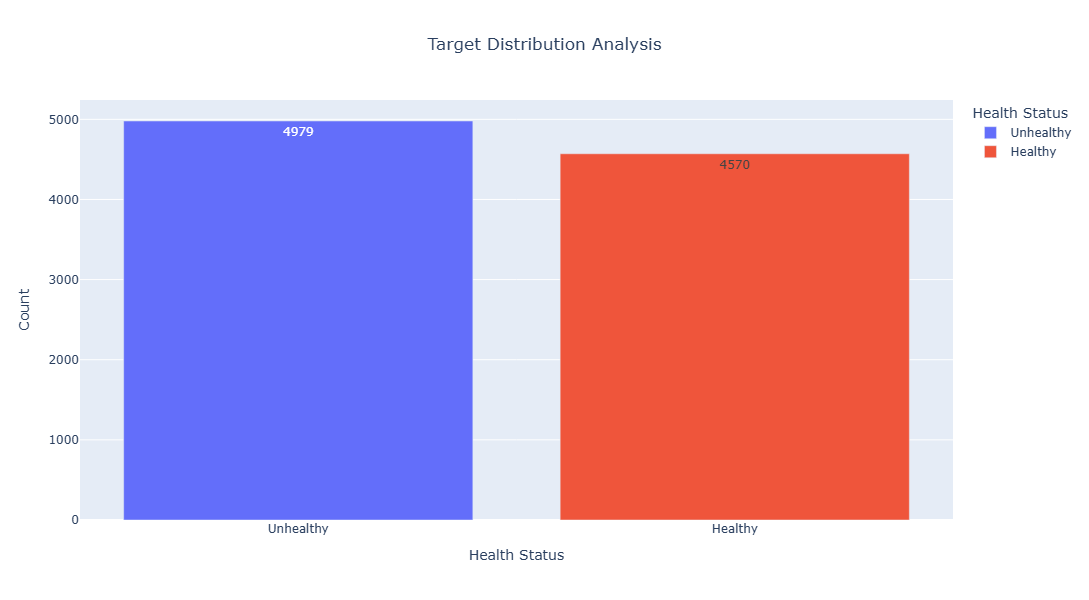

In [24]:
import plotly.express as px

# Count target values
target_counts = df['Target'].value_counts().reset_index()

target_counts.columns = ['Health Status', 'Count']

# Convert target labels for better readability
target_counts['Health Status'] = target_counts['Health Status'].map({
    0: 'Healthy',
    1: 'Unhealthy'
})

# Create interactive bar chart
fig = px.bar(
    target_counts,
    x='Health Status',
    y='Count',
    color='Health Status',
    text='Count',
    title='Target Distribution Analysis'
)

# Customize layout
fig.update_layout(
    title_x=0.5,
    width=900,
    height=600
)

# Show chart
fig.show()

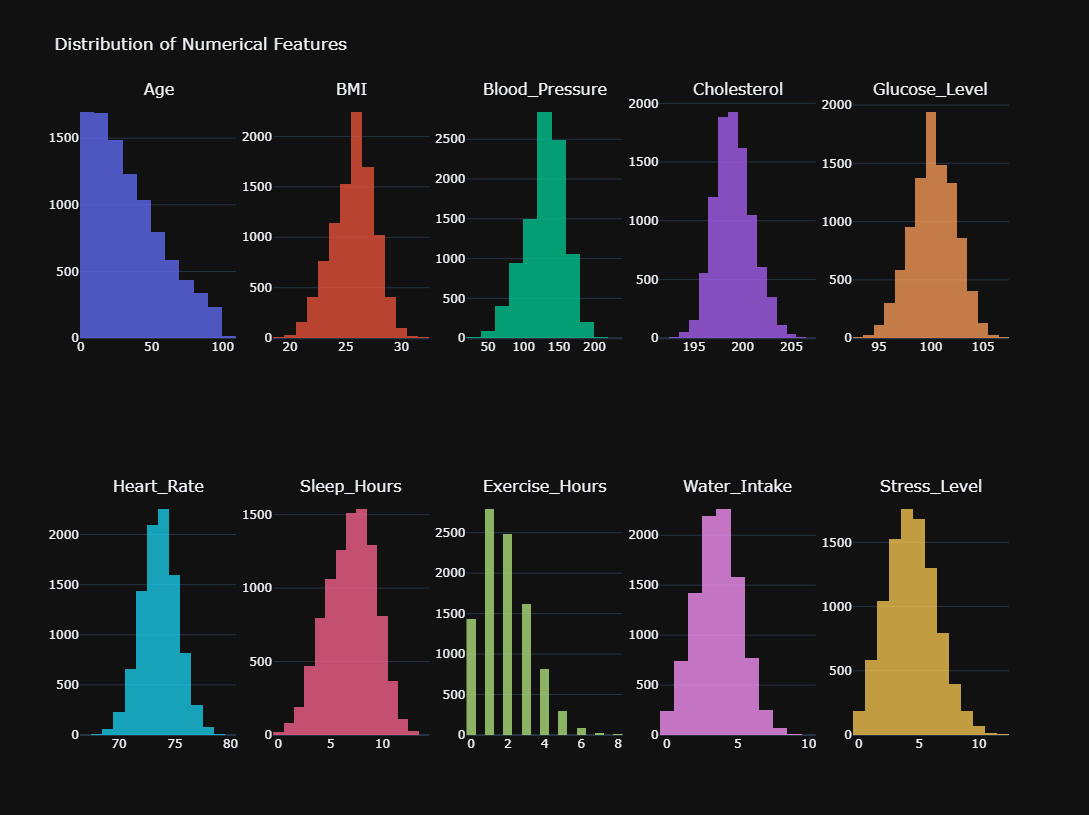

In [25]:
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

numerical_columns = [
    'Age',
    'BMI',
    'Blood_Pressure',
    'Cholesterol',
    'Glucose_Level',
    'Heart_Rate',
    'Sleep_Hours',
    'Exercise_Hours',
    'Water_Intake',
    'Stress_Level'
]

# Create subplot figure
fig = make_subplots(
    rows=2,
    cols=5,
    subplot_titles=numerical_columns
)

# Add histogram for each feature
for idx, column in enumerate(numerical_columns):

    row = idx // 5 + 1
    col = idx % 5 + 1

    fig.add_trace(
        go.Histogram(
            x=df[column],
            nbinsx=20,
            name=column,
            opacity=0.75
        ),
        row=row,
        col=col
    )

# Update layout
fig.update_layout(
    title='Distribution of Numerical Features',
    height=800,
    width=1800,
    showlegend=False,
    template='plotly_dark'
)

# Show plot
fig.show()

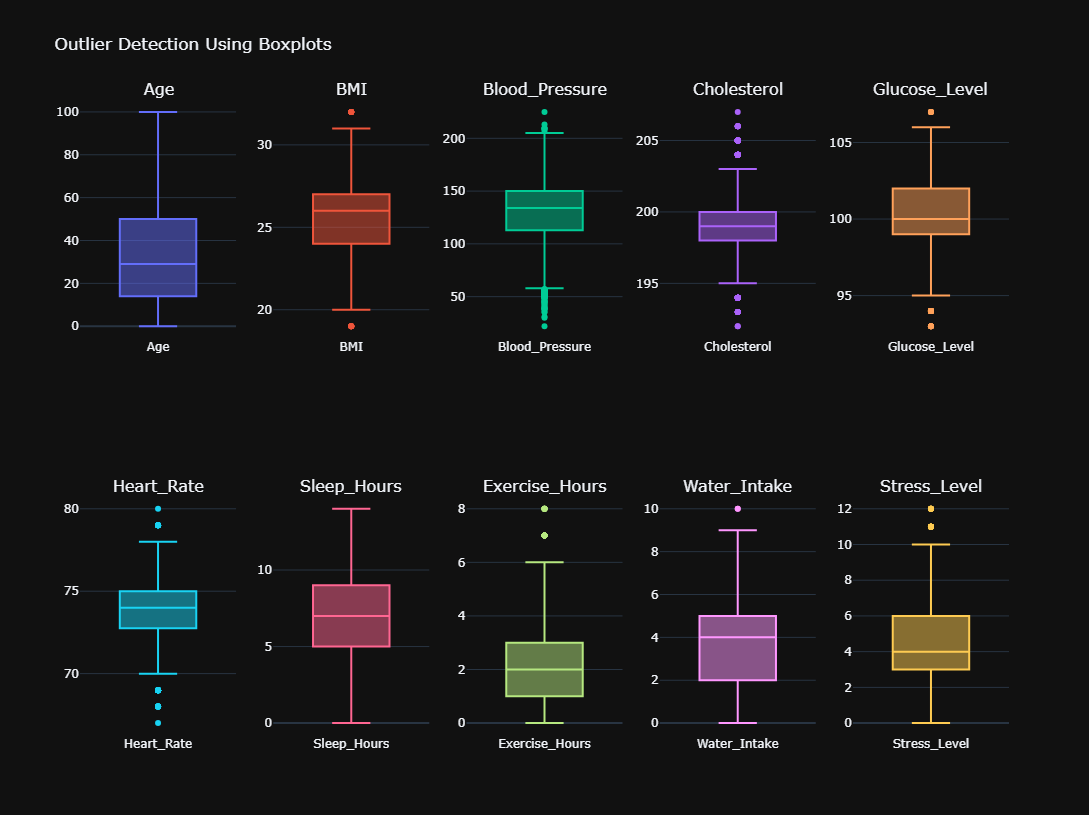

In [26]:
fig = make_subplots(
    rows=2,
    cols=5,
    subplot_titles=numerical_columns
)

for idx, column in enumerate(numerical_columns):

    row = idx // 5 + 1
    col = idx % 5 + 1

    fig.add_trace(
        go.Box(
            y=df[column],
            name=column
        ),
        row=row,
        col=col
    )

fig.update_layout(
    title='Outlier Detection Using Boxplots',
    height=800,
    width=1800,
    showlegend=False,
    template='plotly_dark'
)

fig.show()

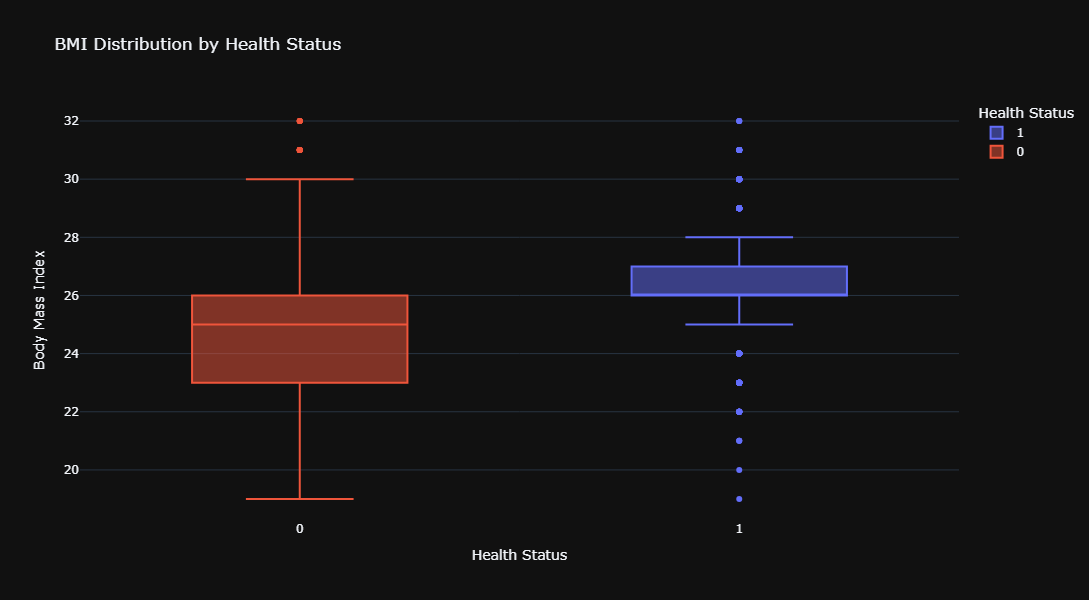

In [27]:
fig = px.box(
    df,
    x='Target',
    y='BMI',
    color='Target',
    title='BMI Distribution by Health Status',
    labels={
        'Target': 'Health Status',
        'BMI': 'Body Mass Index'
    }
)

fig.update_layout(
    template='plotly_dark',
    width=900,
    height=600
)

fig.show()

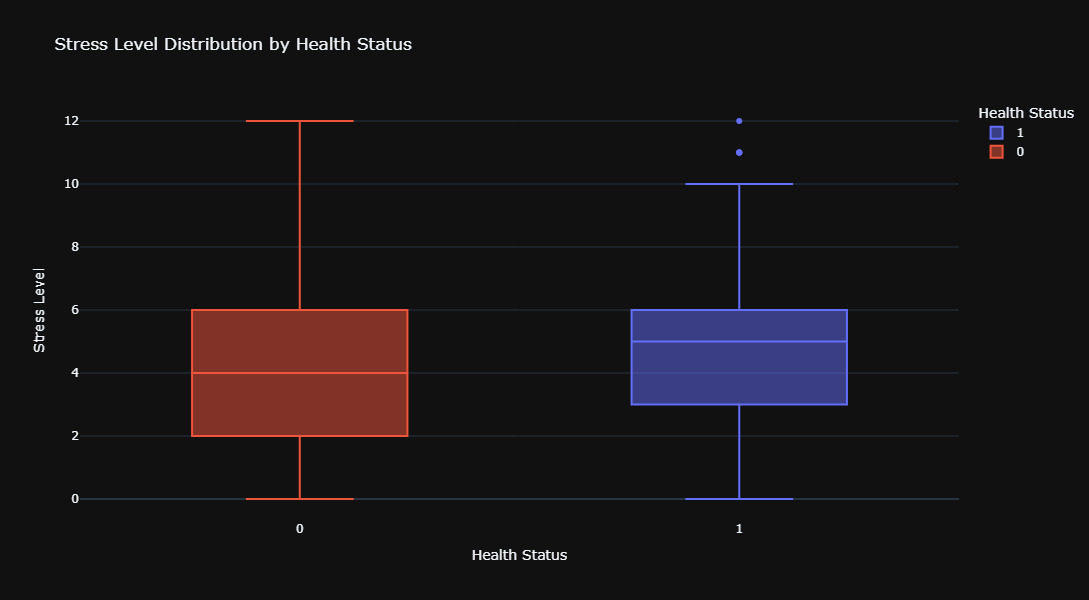

In [28]:
fig = px.box(
    df,
    x='Target',
    y='Stress_Level',
    color='Target',
    title='Stress Level Distribution by Health Status',
    labels={
        'Target': 'Health Status',
        'Stress_Level': 'Stress Level'
    }
)

fig.update_layout(
    template='plotly_dark',
    width=900,
    height=600
)

fig.show()

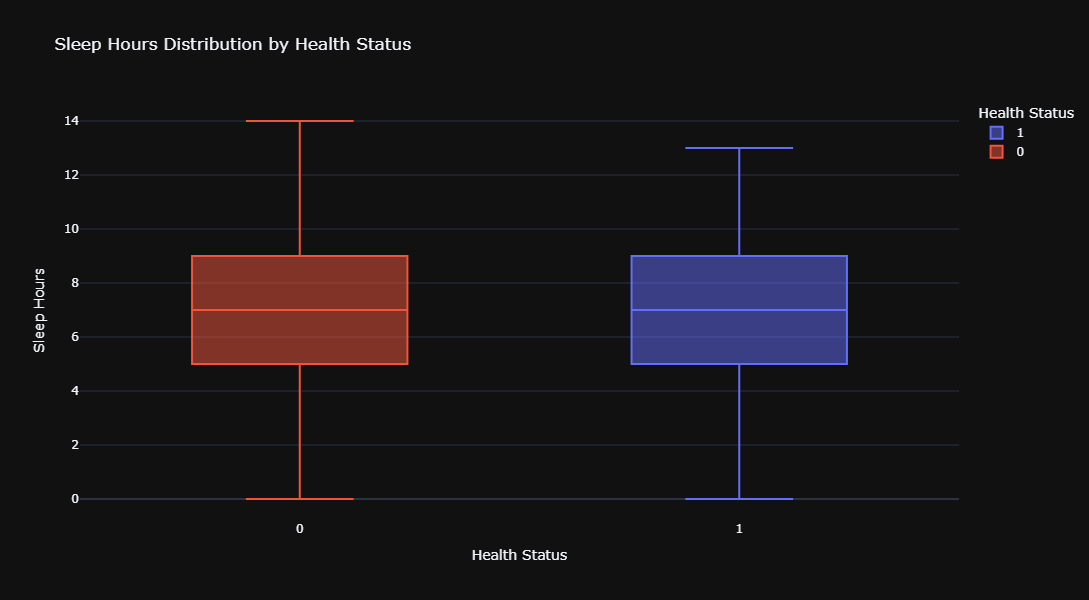

In [29]:
fig = px.box(
    df,
    x='Target',
    y='Sleep_Hours',
    color='Target',
    title='Sleep Hours Distribution by Health Status',
    labels={
        'Target': 'Health Status',
        'Sleep_Hours': 'Sleep Hours'
    }
)

fig.update_layout(
    template='plotly_dark',
    width=900,
    height=600
)

fig.show()

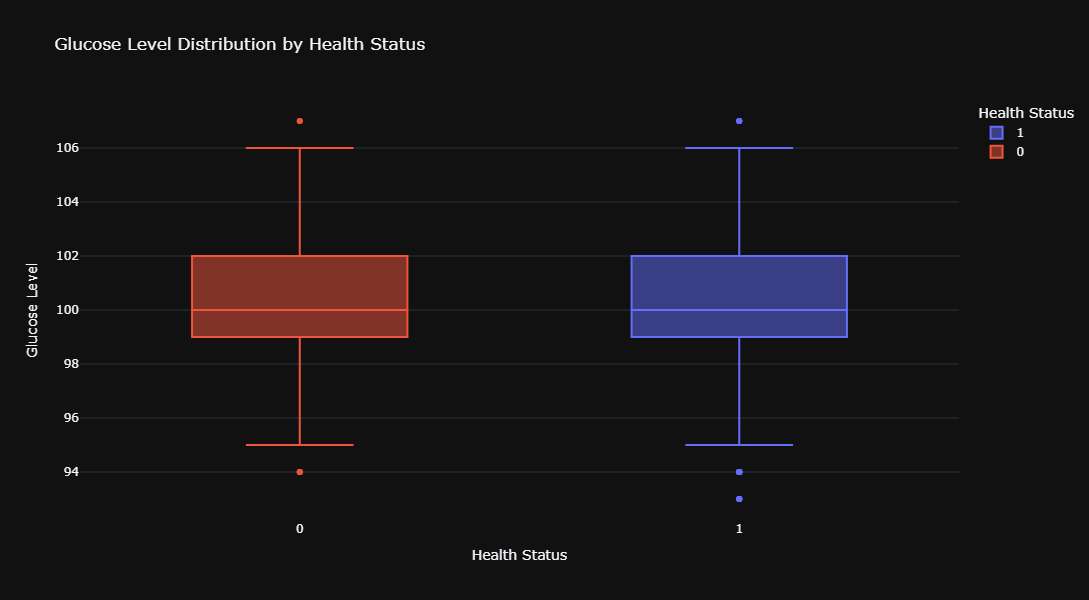

In [30]:
fig = px.box(
    df,
    x='Target',
    y='Glucose_Level',
    color='Target',
    title='Glucose Level Distribution by Health Status',
    labels={
        'Target': 'Health Status',
        'Glucose_Level': 'Glucose Level'
    }
)

fig.update_layout(
    template='plotly_dark',
    width=900,
    height=600
)

fig.show()

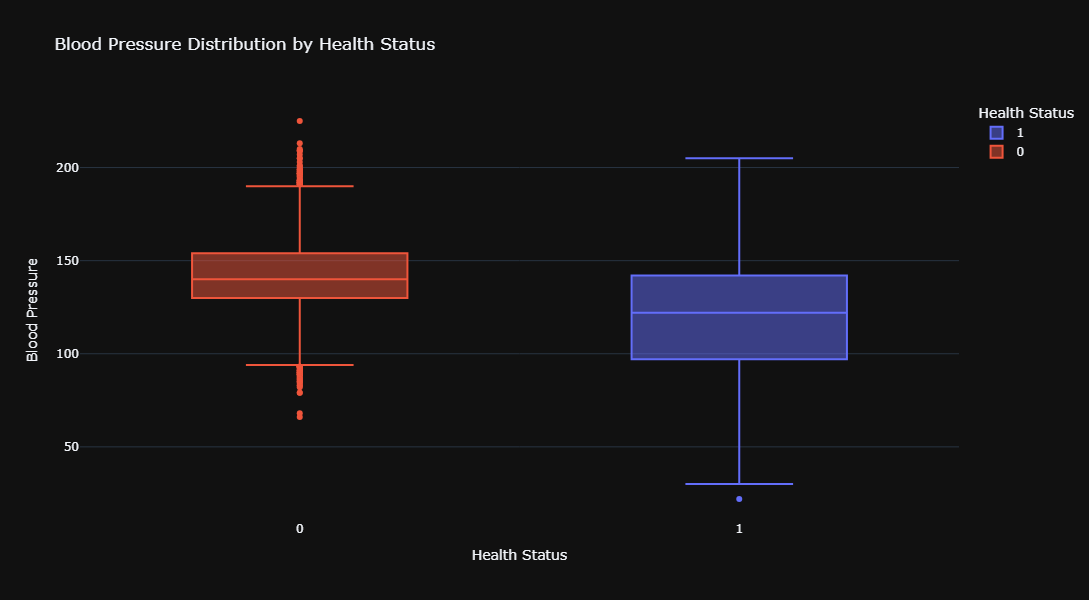

In [15]:

fig = px.box(
    df,
    x='Target',
    y='Blood_Pressure',
    color='Target',
    title='Blood Pressure Distribution by Health Status',
    labels={
        'Target': 'Health Status',
        'Blood_Pressure': 'Blood Pressure'
    }
)

fig.update_layout(
    template='plotly_dark',
    width=900,
    height=600
)

fig.show()

In [31]:
# Features
X = df.drop('Target', axis=1)

# Target
y = df['Target']

# Display shapes
print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (9549, 22)
Target Shape: (9549,)


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display shapes
print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (7639, 22)
X_test Shape: (1910, 22)
y_train Shape: (7639,)
y_test Shape: (1910,)


In [33]:
scaler = StandardScaler()

# Fit and transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data
X_test_scaled = scaler.transform(X_test)

# Display shapes
print("Scaled X_train Shape:", X_train_scaled.shape)
print("Scaled X_test Shape:", X_test_scaled.shape)

Scaled X_train Shape: (7639, 22)
Scaled X_test Shape: (1910, 22)


In [34]:
lr_model = LogisticRegression()

# Train model
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)

# Accuracy
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.8225130890052356


In [35]:
print("Classification Report:\n")

print(classification_report(y_test, y_pred_lr))

# Confusion Matrix
print("Confusion Matrix:\n")

print(confusion_matrix(y_test, y_pred_lr))

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.81      0.81       900
           1       0.83      0.84      0.83      1010

    accuracy                           0.82      1910
   macro avg       0.82      0.82      0.82      1910
weighted avg       0.82      0.82      0.82      1910

Confusion Matrix:

[[725 175]
 [164 846]]


In [36]:
dt_model = DecisionTreeClassifier(random_state=42)

# Train model
dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)

# Accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.8926701570680629


In [37]:
print("Classification Report:\n")

print(classification_report(y_test, y_pred_dt))

# Confusion Matrix
print("Confusion Matrix:\n")

print(confusion_matrix(y_test, y_pred_dt))

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.90      0.89       900
           1       0.91      0.89      0.90      1010

    accuracy                           0.89      1910
   macro avg       0.89      0.89      0.89      1910
weighted avg       0.89      0.89      0.89      1910

Confusion Matrix:

[[807  93]
 [112 898]]


In [38]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9403141361256544


In [39]:

# Classification Report
print("Classification Report:\n")

print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
print("Confusion Matrix:\n")

print(confusion_matrix(y_test, y_pred_rf))

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.94      0.94       900
           1       0.95      0.94      0.94      1010

    accuracy                           0.94      1910
   macro avg       0.94      0.94      0.94      1910
weighted avg       0.94      0.94      0.94      1910

Confusion Matrix:

[[847  53]
 [ 61 949]]


In [40]:
model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

print(model_comparison)

                 Model  Accuracy
0  Logistic Regression  0.822513
1        Decision Tree  0.892670
2        Random Forest  0.940314


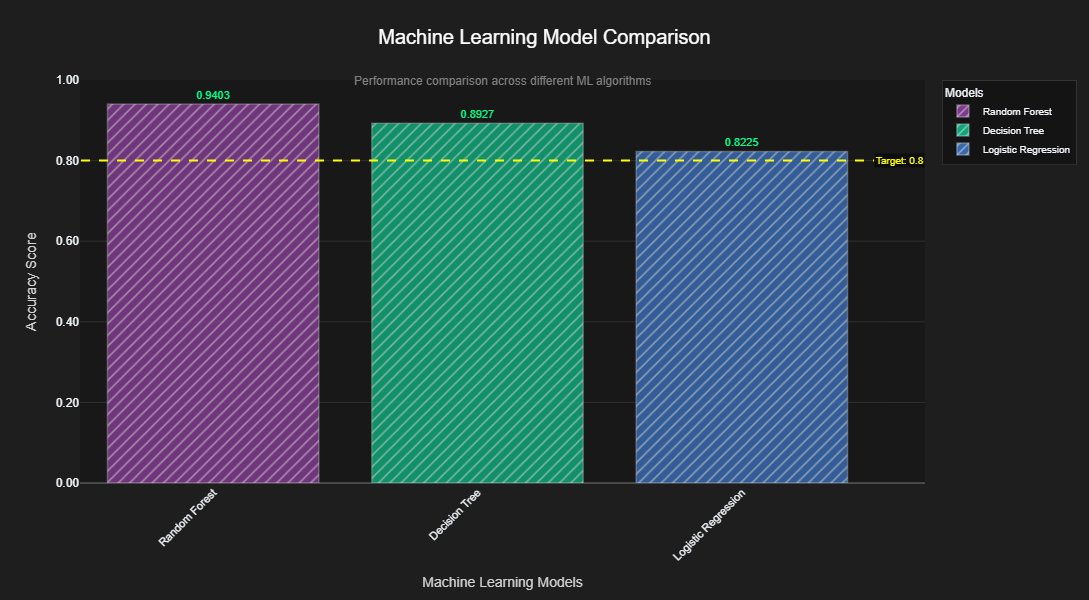

In [42]:
import plotly.express as px
import plotly.graph_objects as go

fig = px.bar(
    model_comparison,
    x='Model',
    y='Accuracy',
    color='Model',
    text='Accuracy',
    title='Machine Learning Model Comparison',
    color_discrete_sequence=px.colors.qualitative.Bold,  # Custom color palette
    category_orders={"Model": model_comparison.sort_values('Accuracy', ascending=False)['Model'].tolist()}  # Sort by accuracy
)

# Enhanced trace formatting
fig.update_traces(
    texttemplate='%{text:.4f}',
    textposition='outside',
    textfont=dict(
        family="Arial, sans-serif",
        size=12,
        color="white"
    ),
    marker=dict(
        line=dict(
            color='rgba(255, 255, 255, 0.3)',
            width=1.5
        ),
        opacity=0.85,
        pattern=dict(  # Add pattern fills
            shape="/",
            size=8
        )
    ),
    hovertemplate='<b>%{x}</b><br>' +
                  'Accuracy: <b>%{y:.4f}</b><br>' +
                  '<extra></extra>',  # Custom hover info
    textfont_size=13
)

# Advanced layout customization
fig.update_layout(
    template='plotly_dark',
    width=1000,
    height=600,
    yaxis=dict(
        range=[0, 1],
        title='Accuracy Score',
        title_font=dict(size=14, family="Arial", color="lightgray"),
        tickformat='.2f',  # Format ticks to 2 decimal places
        tickfont=dict(size=12),
        gridcolor='rgba(255, 255, 255, 0.1)',
        gridwidth=1,
        zeroline=True,
        zerolinecolor='rgba(255, 255, 255, 0.2)',
        zerolinewidth=2,
        showgrid=True
    ),
    xaxis=dict(
        title='Machine Learning Models',
        title_font=dict(size=14, family="Arial", color="lightgray"),
        tickfont=dict(size=11),
        tickangle=-45,  # Angle the labels if needed
        categoryorder='total descending'  # Sort bars by value
    ),
    title=dict(
        text='Machine Learning Model Comparison',
        font=dict(size=20, family="Arial", color="white"),
        x=0.5,  # Center title
        xanchor='center',
        y=0.95
    ),
    font=dict(family="Arial, sans-serif"),
    plot_bgcolor='rgba(0, 0, 0, 0.2)',  # Slightly transparent plot background
    paper_bgcolor='#1e1e1e',  # Darker paper background
    margin=dict(l=80, r=40, t=80, b=80),  # Custom margins
    legend=dict(
        title='Models',
        font=dict(size=10),
        bgcolor='rgba(0, 0, 0, 0.3)',
        bordercolor='rgba(255, 255, 255, 0.1)',
        borderwidth=1
    ),
    shapes=[  # Add reference line for target accuracy
        dict(
            type='line',
            y0=0.8, y1=0.8,
            x0=-0.5, x1=len(model_comparison)-0.5,
            line=dict(
                color='yellow',
                width=2,
                dash='dash'
            ),
            name='Target Accuracy (0.8)'
        )
    ],
    annotations=[  # Add annotation for target line
        dict(
            x=len(model_comparison)-0.5,
            y=0.8,
            text='Target: 0.8',
            showarrow=False,
            font=dict(color='yellow', size=10),
            xanchor='left',
            bgcolor='rgba(0,0,0,0.5)'
        )
    ]
)

# Add value labels on top of bars with background
fig.update_traces(
    textposition='outside',
    texttemplate='%{text:.4f}',
    textfont=dict(
        family="Arial, sans-serif",
        size=11,
        color="#00ff88"  # Neon green text
    )
)

# Optional: Add a subtitle as an annotation
fig.add_annotation(
    text="Performance comparison across different ML algorithms",
    xref="paper", yref="paper",
    x=0.5, y=1.02,
    showarrow=False,
    font=dict(size=12, color="gray"),
    xanchor="center"
)

fig.show()

In [43]:
# Create dataframe
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

# Sort values
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Display top features
print(feature_importance)

                  Feature  Importance
1                     BMI    0.216977
2          Blood_Pressure    0.153406
3             Cholesterol    0.100800
9            Stress_Level    0.080386
4           Glucose_Level    0.073195
6             Sleep_Hours    0.071964
0                     Age    0.070011
5              Heart_Rate    0.052353
8            Water_Intake    0.050424
7          Exercise_Hours    0.027110
16              Allergies    0.011081
15         MedicalHistory    0.011061
13           MentalHealth    0.011016
11                Alcohol    0.010999
14       PhysicalActivity    0.010650
10                Smoking    0.010499
12                   Diet    0.010383
18  Diet_Type__Vegetarian    0.006000
17       Diet_Type__Vegan    0.005908
20          Blood_Group_B    0.005464
19         Blood_Group_AB    0.005362
21          Blood_Group_O    0.004952


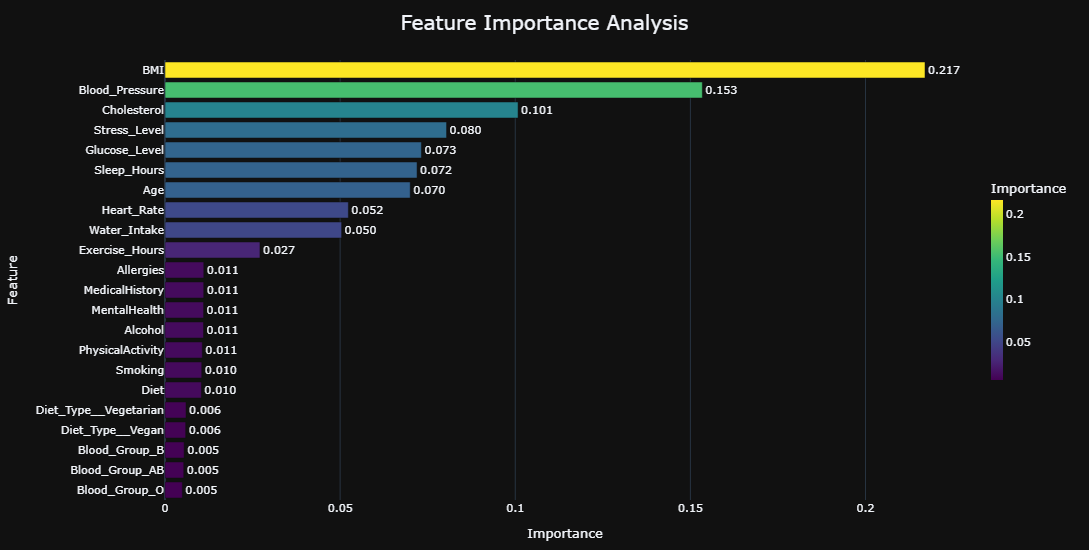

In [46]:
import plotly.express as px

# Sort feature importance
feature_importance = feature_importance.sort_values(
    'Importance',
    ascending=True
)

# Create compact chart
fig = px.bar(
    feature_importance,
    x='Importance',
    y='Feature',
    orientation='h',
    color='Importance',
    text='Importance',
    color_continuous_scale='Viridis',
    title='Feature Importance Analysis'
)

# Clean professional styling
fig.update_traces(
    texttemplate='%{text:.3f}',
    textposition='outside'
)

# Compact LinkedIn-friendly layout
fig.update_layout(
    template='plotly_dark',
    width=850,
    height=550,
    
    title=dict(
        x=0.5,
        font=dict(size=20)
    ),

    font=dict(size=11),

    margin=dict(
        l=20,
        r=20,
        t=60,
        b=20
    ),

    coloraxis_colorbar=dict(
        title='Importance',
        thickness=12,
        len=0.5
    )
)

fig.show()

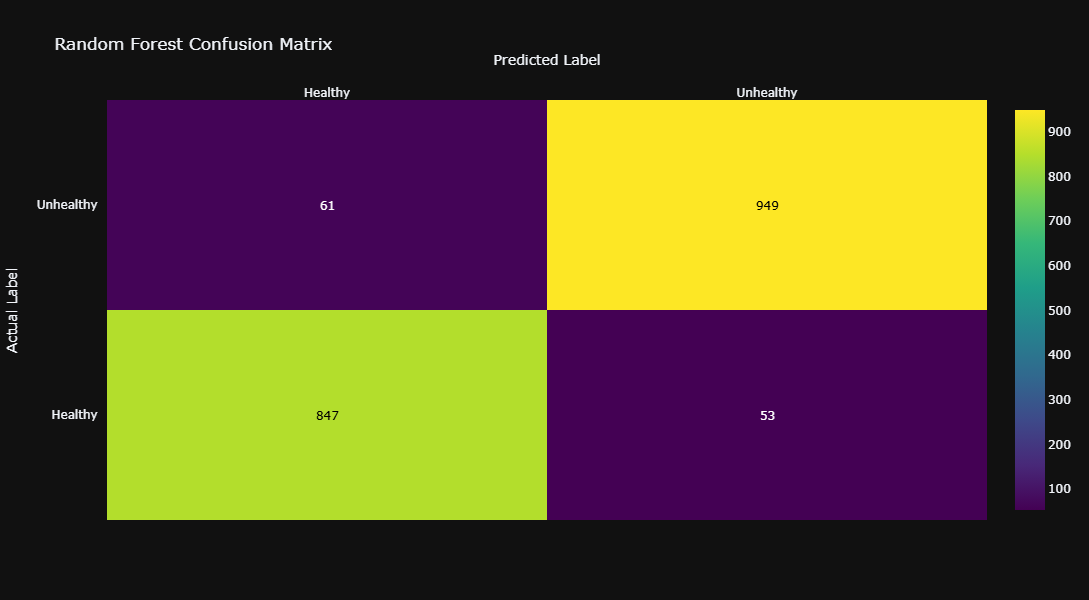

In [47]:
import plotly.figure_factory as ff
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

# Labels
labels = ['Healthy', 'Unhealthy']

# Create heatmap
fig = ff.create_annotated_heatmap(
    z=cm,
    x=labels,
    y=labels,
    colorscale='Viridis',
    showscale=True
)

# Update layout
fig.update_layout(
    title='Random Forest Confusion Matrix',
    template='plotly_dark',
    width=700,
    height=600,

    xaxis_title='Predicted Label',
    yaxis_title='Actual Label'
)

fig.show()

In [48]:
print("Final Project Conclusion")

print("\nBest Performing Model: Random Forest")

print(f"\nRandom Forest Accuracy: {rf_accuracy:.4f}")

print("\nTop Important Features:")
print(feature_importance.sort_values(
    by='Importance',
    ascending=False
).head())

print("\nThe Random Forest model achieved the highest accuracy")
print("and provided the most reliable healthcare risk predictions.")

Final Project Conclusion

Best Performing Model: Random Forest

Random Forest Accuracy: 0.9403

Top Important Features:
          Feature  Importance  Pct_Total
1             BMI    0.216977       21.7
2  Blood_Pressure    0.153406       15.3
3     Cholesterol    0.100800       10.1
9    Stress_Level    0.080386        8.0
4   Glucose_Level    0.073195        7.3

The Random Forest model achieved the highest accuracy
and provided the most reliable healthcare risk predictions.


In [49]:
import joblib

# Save model
joblib.dump(rf_model, 'health_risk_model.pkl')

print("Model Saved Successfully")

Model Saved Successfully
